In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [12]:
train = pd.read_csv('C:/Users/mickt/Downloads/conversion_data_train.csv')
test = pd.read_csv('C:/Users/mickt/Downloads/conversion_data_test.csv')

In [13]:
train.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [14]:
train.shape

(284580, 6)

In [15]:
test.head()

,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


In [16]:
test.shape

(31620, 5)

## EDA

In [18]:
train.country.value_counts()

country
US         160124
China       69122
UK          43641
Germany     11693
Name: count, dtype: int64

In [ ]:
train.groupby('country')['age'].mean()

country
China      30.664014
Germany    30.457966
UK         30.433675
US         30.564450
Name: age, dtype: float64

In [43]:
train.groupby('country')['age'].std()

country
China      8.275166
Germany    8.293478
UK         8.239715
US         8.268073
Name: age, dtype: float64

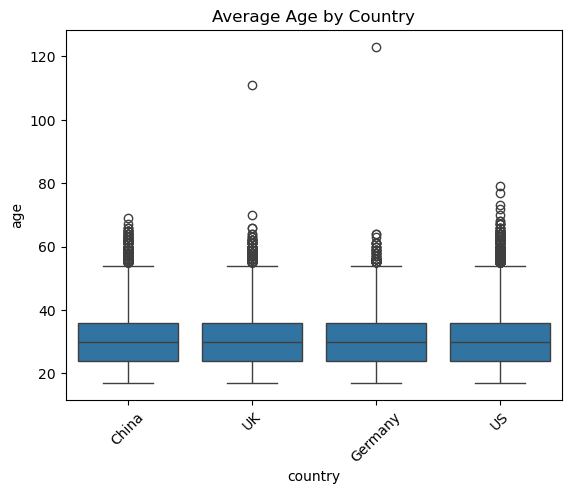

<Figure size 1000x1500 with 0 Axes>

In [36]:
sns.boxplot(x=train['country'], y=train['age'])
plt.title('Average Age by Country')
plt.xticks(rotation=45)
plt.figure(figsize=(10, 15))
plt.show()

In [70]:
train[train['country'] == 'US']

,country,age,new_user,source,total_pages_visited,converted
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0
5,US,29,0,Seo,7,0
6,US,30,1,Direct,4,0
10,US,31,1,Direct,1,0
...,...,...,...,...,...,...
284575,US,36,1,Ads,1,0
284576,US,31,1,Seo,2,0
284577,US,41,1,Seo,5,0
284578,US,31,1,Direct,4,0


In [44]:
train.new_user.value_counts()

new_user
1    195066
0     89514
Name: count, dtype: int64

In [48]:
train.groupby('new_user')['age'].mean()

new_user
0    30.421722
1    30.629587
Name: age, dtype: float64

In [49]:
train.groupby('source')['new_user'].value_counts()

source  new_user
Ads     1           54932
        0           25095
Direct  1           44652
        0           20424
Seo     1           95482
        0           43995
Name: count, dtype: int64

In [52]:
train.groupby('country')['total_pages_visited'].mean()

country
China      4.551604
Germany    5.207646
UK         5.078985
US         4.931609
Name: total_pages_visited, dtype: float64

In [53]:
train.groupby('new_user')['total_pages_visited'].mean()

new_user
0    5.282660
1    4.685378
Name: total_pages_visited, dtype: float64

In [69]:
train.converted.value_counts()

converted
0    275400
1      9180
Name: count, dtype: int64

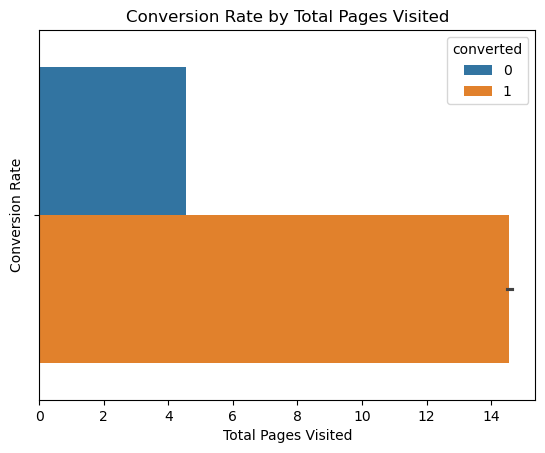

In [72]:
sns.barplot(x = 'total_pages_visited', hue = 'converted', data = train)
plt.title('Conversion Rate by Total Pages Visited')
plt.xlabel('Total Pages Visited')
plt.ylabel('Conversion Rate')
plt.show()

## Model

In [55]:
prepocessed_train = pd.get_dummies(train, columns=['country', 'source'], drop_first=True)
prepocessed_train.head()

,age,new_user,total_pages_visited,converted,country_Germany,country_UK,country_US,source_Direct,source_Seo
0,22,1,2,0,False,False,False,True,False
1,21,1,3,0,False,True,False,False,False
2,20,0,14,1,True,False,False,False,True
3,23,1,3,0,False,False,True,False,True
4,28,1,3,0,False,False,True,True,False


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55058
           1       0.85      0.69      0.76      1858

    accuracy                           0.99     56916
   macro avg       0.92      0.85      0.88     56916
weighted avg       0.99      0.99      0.99     56916

[[54825   233]
 [  567  1291]]
0.9872129560915917


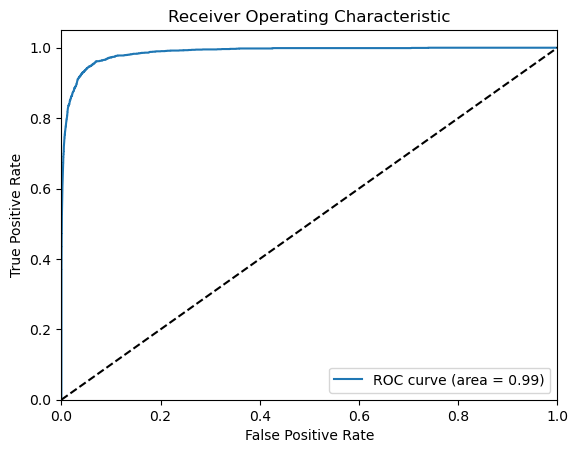

In [81]:
x = prepocessed_train.drop('converted', axis=1)
y = prepocessed_train['converted']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
y_pred_proba = model.predict_proba(x_test)[:, 1]
print(roc_auc_score(y_test, y_pred_proba))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [78]:
from sklearn.metrics import f1_score

y_proba = best_model.predict_proba(x_test)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba > t).astype(int)
    print(f"Threshold {t}: F1 = {f1_score(y_test, y_pred)}")

Threshold 0.3: F1 = 0.7622304050499737
Threshold 0.4: F1 = 0.770962296004502
Threshold 0.5: F1 = 0.7632279042270175
Threshold 0.6: F1 = 0.7442439327940261
Threshold 0.7: F1 = 0.7140983606557377


Best parameters found:  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55058
           1       0.85      0.69      0.76      1858

    accuracy                           0.99     56916
   macro avg       0.92      0.85      0.88     56916
weighted avg       0.99      0.99      0.99     56916

[[54827   231]
 [  567  1291]]
0.9872009616945294


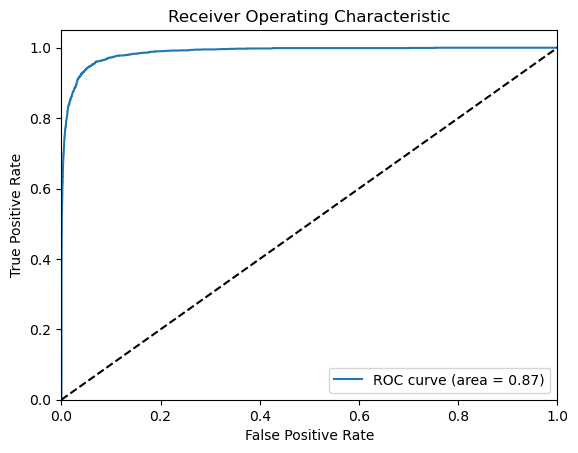

In [82]:
gridsearch_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=gridsearch_params, cv=5, scoring='roc_auc')
grid_search.fit(x_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
y_proba_best = best_model.predict_proba(x_test)[:, 1]
y_pred_best = (y_proba_best > 0.4).astype(int)
print(roc_auc_score(y_test, y_proba_best))
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_best))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Hyperparameter tuning did not improve the model